In [36]:
""" Loading the data """
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

emotion_df = pd.read_csv('/nlp-sentiment-analysis/Datasets/emotions.csv')
emotion_df.head()

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4


In [2]:
gbv_hate_speech_df = pd.read_csv('/nlp-sentiment-analysis/Datasets/gbv_hate_speech.csv')
gbv_hate_speech_df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [3]:
violence_df = pd.read_csv('/nlp-sentiment-analysis/Datasets/violence.csv')
violence_df.head()

,Tweet_ID,tweet,type
0,ID_0022DWKP,Had a dream i got raped last night. By a guy i...,sexual_violence
1,ID_00395QYM,he thought the word raped means sex and told m...,sexual_violence
2,ID_003EOSSF,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,sexual_violence
3,ID_004BBHOD,I was sexually abused for 3 years at age 4 to ...,sexual_violence
4,ID_004F7516,Chessy Prout can do better by telling the trut...,sexual_violence


In [4]:
""" Data Preprocessing """
# Dropping unwanted columns
emotion_df.drop(columns = ['Unnamed: 0'], inplace = True)
violence_df.drop(columns = ['Tweet_ID'], inplace = True)
gbv_hate_speech_df = gbv_hate_speech_df[['tweet', 'class']]

In [5]:
emotion_df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [6]:
violence_df.head()

,tweet,type
0,Had a dream i got raped last night. By a guy i...,sexual_violence
1,he thought the word raped means sex and told m...,sexual_violence
2,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,sexual_violence
3,I was sexually abused for 3 years at age 4 to ...,sexual_violence
4,Chessy Prout can do better by telling the trut...,sexual_violence


In [7]:
gbv_hate_speech_df.head()

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [8]:
# Renaming the columns
violence_df.rename(columns = {'tweet' : 'text', 'type' : 'label'}, inplace = True)
gbv_hate_speech_df.rename(columns = {'tweet' : 'text', 'class' : 'label'}, inplace = True)

violence_df.columns, gbv_hate_speech_df.columns, emotion_df.columns

(Index(['text', 'label'], dtype='object'),
 Index(['text', 'label'], dtype='object'),
 Index(['text', 'label'], dtype='object'))

In [9]:
# Checking for null values
violence_df.isna().sum(), gbv_hate_speech_df.isna().sum(), emotion_df.isna().sum()

(text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64)

In [10]:
# Data sampling: extracting 12 thousand rows from each dataset.
emtn_df = pd.DataFrame()
for i in range(6):
    subset = emotion_df[emotion_df['label'] == i].sample(n = 2000, random_state = 42)
    emtn_df = pd.concat([emtn_df, subset])

emotion_df = emtn_df.copy()
emotion_df['label'].value_counts()
emotion_df.shape

(12000, 2)

In [11]:
violence_df['label'].value_counts()

label
sexual_violence                 32648
Physical_violence                5946
emotional_violence                651
economic_violence                 217
Harmful_Traditional_practice      188
Name: count, dtype: int64

In [12]:
# Because violence_df has uneven counts in the columns, we only sample from the highest(sexual_violence).
sexual_violence = violence_df[violence_df['label'] == 'sexual_violence'].sample(n = 4998, random_state = 42)

# Removing 'sexual_violence' column from violence_df
violence_df = violence_df[violence_df['label'] != 'sexual_violence']

# Re-adding sampled 'sexual_violence' column to violence_df
violence_df = pd.concat( [sexual_violence, violence_df], axis = 0)

violence_df.shape

(12000, 2)

In [13]:
gbv_hate_speech_df['label'].value_counts()

label
1    19190
2     4163
0     1430
Name: count, dtype: int64

In [14]:
# Because gbv_hate_speech_df has uneven counts in the columns, we only sample from the highest(offensive_speech) column.
offensive_speech = gbv_hate_speech_df[gbv_hate_speech_df['label'] == 1].sample(n = 6407, random_state = 42)

# Removing 'offensive_speech' from gbv_hate_speech_df
gbv_hate_speech_df = gbv_hate_speech_df[gbv_hate_speech_df['label'] != 1]

# Re-adding sampled 'offensive_speech' column to gbv_hate_speech_df
gbv_hate_speech_df = pd.concat([offensive_speech, gbv_hate_speech_df], axis = 0)

gbv_hate_speech_df.shape

(12000, 2)

In [15]:
# Resetting indexes of dataframes
emotion_df.reset_index(drop = True, inplace = True)
gbv_hate_speech_df.reset_index(drop = True, inplace = True)
violence_df.reset_index(drop = True, inplace = True)

In [16]:
emotion_df.head(3)

,text,label
0,ive learned to surround myself with women who ...,0
1,i already feel crappy because of this and you ...,0
2,i feel like i have lost mourned and moved past...,0


In [17]:
gbv_hate_speech_df.head(3)

,text,label
0,Why is it everytime I go to cracker barrel the...,1
1,"Run that nigga, you don't want that nigga, but...",1
2,I need a girl from Jamaica I can't fuck with t...,1


In [18]:
violence_df.head(3)

,text,label
0,My cousin was raped by this guy Matthew. She w...,sexual_violence
1,HAHAHAHAHAHAHHA I DIDN’T SEE IT THE FIRST TIME...,sexual_violence
2,I remember how I almost got raped like it was ...,sexual_violence


In [19]:
""" Label encoding """
label_encoder = LabelEncoder()
violence_df['label'] = label_encoder.fit_transform(violence_df['label'])

violence_df.head()

,text,label
0,My cousin was raped by this guy Matthew. She w...,4
1,HAHAHAHAHAHAHHA I DIDN’T SEE IT THE FIRST TIME...,4
2,I remember how I almost got raped like it was ...,4
3,He raped me 👈,4
4,"A woman raped by A male: psychological horror,...",4


In [20]:
""" Stopwords Removal """
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tobos\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tobos\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
# Loading the stopwords
stop_words = set(stopwords.words('english'))

len(stop_words)

198

In [22]:
# Stopwords removal function
def remove_stopwords(text):
    all_words = nltk.word_tokenize(text)
    filtered_words = [word for word in all_words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

emotion_df['text'] = emotion_df['text'].apply(remove_stopwords)
violence_df['text'] = violence_df['text'].apply(remove_stopwords)
gbv_hate_speech_df['text'] = gbv_hate_speech_df['text'].apply(remove_stopwords)

emotion_df.head(5)

,text,label
0,ive learned surround women lift leave feeling ...,0
1,already feel crappy upset situation doesnt help,0
2,feel like lost mourned moved past tears relati...,0
3,could write whole lot im feeling crappy dont t...,0
4,always seem feel inadequate,0


In [23]:
""" Tokenization & Padding """
tokenizer = Tokenizer()
tokenizer.fit_on_texts(pd.concat([violence_df['text'],emotion_df['text'],  gbv_hate_speech_df['text']]))

emotion_sequences = tokenizer.texts_to_sequences(emotion_df['text'])
violence_sequences = tokenizer.texts_to_sequences(violence_df['text'])
gbv_hate_speech_sequences = tokenizer.texts_to_sequences(gbv_hate_speech_df['text'])

In [24]:
emotion_df['text'].iloc[2]

'feel like lost mourned moved past tears relationship'

In [25]:
emotion_sequences[2:3]

[[1, 5, 322, 12790, 1209, 423, 1096, 386]]

In [26]:
max_length = 50
emotion_padded = pad_sequences(emotion_sequences, maxlen = max_length, padding = 'post')
violence_padded = pad_sequences(violence_sequences, maxlen = max_length, padding = 'post')
gbv_hate_speech_padded = pad_sequences(gbv_hate_speech_sequences, maxlen = max_length, padding = 'post')

emotion_padded[2:3]

array([[    1,     5,   322, 12790,  1209,   423,  1096,   386,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0]], dtype=int32)

In [27]:
# Generating labels in numpy array format
emotion_labels = np.array(emotion_df['label'])
violence_labels = np.array(violence_df['label'])
gbv_hate_speech_labels = np.array(gbv_hate_speech_df['label'])

In [28]:
""" Model definition  """

# Prepare separate inputs for each dataset
emotion_input = emotion_padded
violence_input = violence_padded
gbv_hate_speech_input = gbv_hate_speech_padded

# Define multiple input layers for each task
emotion_input_layer = keras.layers.Input(shape = (max_length, ), name = 'emotion_input')
violence_input_layer = keras.layers.Input(shape = (max_length, ), name = 'violence_input')
gbv_hate_speech_input_layer = keras.layers.Input(shape = (max_length, ), name = 'gbv_hate_speech_input')

# Use a shared embedding layer
embedding_layer = keras.layers.Embedding(input_dim = len(tokenizer.word_index) + 1, output_dim = 128)

# Apply the embedding layer to each input
emotion_embedding = embedding_layer(emotion_input_layer)
violence_embedding = embedding_layer(violence_input_layer)
gbv_hate_speech_embedding = embedding_layer(gbv_hate_speech_input_layer)

# Shared LSTM layer
shared_lstm = keras.layers.LSTM(64, return_sequences = True)

emotion_lstm = shared_lstm(emotion_embedding)
violence_lstm = shared_lstm(violence_embedding)
gbv_hate_speech_lstm = shared_lstm(gbv_hate_speech_embedding)

# Share global average pooling layer and dropout layer
shared_pooling = keras.layers.GlobalAveragePooling1D()
shared_dropout = keras.layers.Dropout(0.5)

emotion_features = shared_dropout(shared_pooling(emotion_lstm))
violence_features = shared_dropout(shared_pooling(violence_lstm))
gbv_hate_speech_features = shared_dropout(shared_pooling(gbv_hate_speech_lstm))

# Output layers
emotion_output = keras.layers.Dense(6, activation = 'softmax', name = 'emotion_output')(emotion_features)
violence_output = keras.layers.Dense(5, activation = 'softmax', name = 'violence_output')(violence_features)
gbv_hate_speech_output = keras.layers.Dense(3, activation = 'softmax', name = 'gbv_hate_speech_output')(gbv_hate_speech_features)

In [29]:
# Compile the model with multiple inputs and outputs
model = keras.models.Model(inputs = [emotion_input_layer, violence_input_layer, gbv_hate_speech_input_layer],
                           outputs = [emotion_output, violence_output, gbv_hate_speech_output])

model.compile(optimizer = 'adam',
              loss = {
                  'emotion_output':'sparse_categorical_crossentropy',
                  'violence_output':'sparse_categorical_crossentropy',
                  'gbv_hate_speech_output':'sparse_categorical_crossentropy'
              },
              metrics = {
                  'emotion_output':'accuracy',
                  'violence_output': 'accuracy',
                  'gbv_hate_speech_output': 'accuracy'
              })

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ emotion_input       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ violence_input      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gbv_hate_speech_in… │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  5,350,528 │ emotion_input[0]… │
│ (Embedding)         │                   │            │ violence_input[0… │
│                     │                   │            │ gbv_hate_speech_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 50, 64)    │     49,408 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0],  │
│                     │                   │            │ embedding[2][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ lstm[0][0],       │
│ (GlobalAveragePool… │                   │            │ lstm[1][0],       │
│                     │                   │            │ lstm[2][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ global_average_p… │
│                     │                   │            │ global_average_p… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_output      │ (None, 6)         │        390 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ violence_output     │ (None, 5)         │        325 │ dropout[1][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gbv_hate_speech_ou… │ (None, 3)         │        195 │ dropout[2][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,400,846 (20.60 MB)

 Trainable params: 5,400,846 (20.60 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Training the model with separate inputs.
model.fit(x = {
    'emotion_input': emotion_input,
    'violence_input' : violence_input,
    'gbv_hate_speech_input': gbv_hate_speech_input},
          y = {
    'emotion_output': emotion_labels,
    'violence_output' : violence_labels,
    'gbv_hate_speech_output': gbv_hate_speech_labels},
    epochs = 10, batch_size = 4)


Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 424s 139ms/step - emotion_output_accuracy: 0.2163 - emotion_output_loss: 1.7654 - gbv_hate_speech_output_accuracy: 0.6736 - gbv_hate_speech_output_loss: 0.7652 - loss: 2.9331 - violence_output_accuracy: 0.8589 - violence_output_loss: 0.4025
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 400s 133ms/step - emotion_output_accuracy: 0.7363 - emotion_output_loss: 0.7306 - gbv_hate_speech_output_accuracy: 0.8764 - gbv_hate_speech_output_loss: 0.3663 - loss: 1.1412 - violence_output_accuracy: 0.9838 - violence_output_loss: 0.0443
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 433s 144ms/step - emotion_output_accuracy: 0.9382 - emotion_output_loss: 0.2062 - gbv_hate_speech_output_accuracy: 0.9305 - gbv_hate_speech_output_loss: 0.2067 - loss: 0.4213 - violence_output_accuracy: 0.9989 - violence_output_loss: 0.0085
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 421s 140ms/step - emotion_output_accuracy: 0.9573 - emotion_output_loss: 0.1329 - gbv_hate_speech_output_accu

In [33]:
""" Prediction and Evaluation """
prediction = model.predict({
    'emotion_input': emotion_input,
    'violence_input' : violence_input,
    'gbv_hate_speech_input': gbv_hate_speech_input
})

375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step


In [34]:
prediction

[array([[9.9998021e-01, 2.0912391e-06, 1.7519093e-06, 5.0100198e-06,
         1.0598951e-05, 2.9699194e-07],
        [9.9999809e-01, 1.8141183e-07, 2.4370527e-07, 9.7687405e-07,
         4.2483899e-07, 6.5061667e-09],
        [9.9998128e-01, 1.9248084e-06, 8.9477243e-07, 1.5010457e-05,
         7.2229136e-07, 5.4306490e-08],
        ...,
        [2.0182717e-03, 3.4167268e-04, 1.9210533e-04, 1.5515411e-04,
         1.6682774e-01, 8.3046514e-01],
        [7.4446291e-07, 8.5655944e-07, 2.5218418e-07, 3.8275203e-07,
         8.7421895e-06, 9.9998903e-01],
        [3.0078832e-04, 1.5797283e-04, 6.8590458e-04, 1.1104117e-04,
         2.3429439e-04, 9.9850994e-01]], dtype=float32),
 array([[2.6928221e-10, 2.3542501e-11, 1.1334502e-09, 2.8007169e-10,
         1.0000000e+00],
        [7.1232824e-09, 8.0458671e-09, 2.3269148e-08, 4.7779896e-08,
         1.0000000e+00],
        [7.3914762e-08, 3.2021838e-08, 2.4818735e-07, 7.4213364e-09,
         9.9999964e-01],
        ...,
        [2.2522902e-1

In [38]:
emotion_pred = np.argmax(prediction[0], axis = 1)
violence_pred = np.argmax(prediction[1], axis = 1)
gbv_hate_speech_pred = np.argmax(prediction[2], axis = 1)

In [39]:
def plot_com(true, pred, title, labels):
    cf = confusion_matrix(true, pred, normalize='true')
    plt.figure(figsize = (7,6))
    sns.heatmap(cf,annot = True,cmap = 'Blues', xticklabels = labels, yticklabels = labels)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Prediction')

emotion_labels_text = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
violence_labels_text = ['sexual_violence','physical_violence','emotional_violence','Harmful_traditional_practice','economic violence']
gbv_hate_speech_labels_text = ['offensive speech', 'Neither', 'Hate Speech']

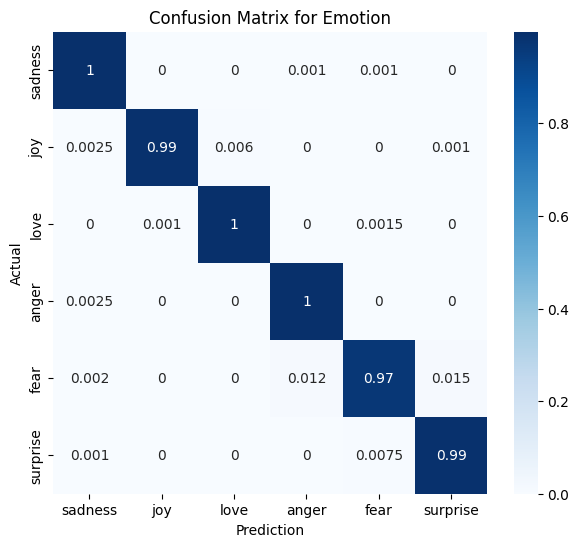

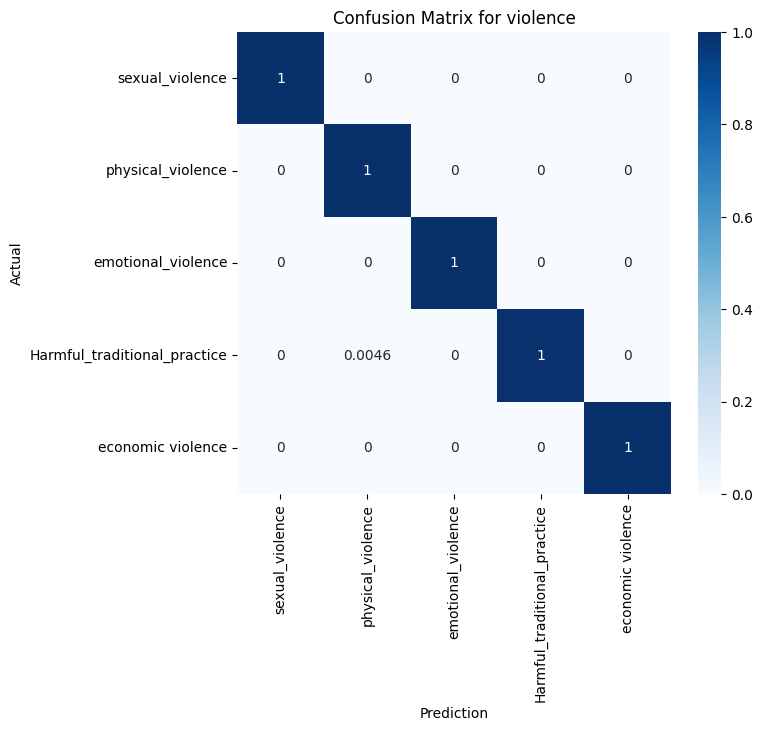

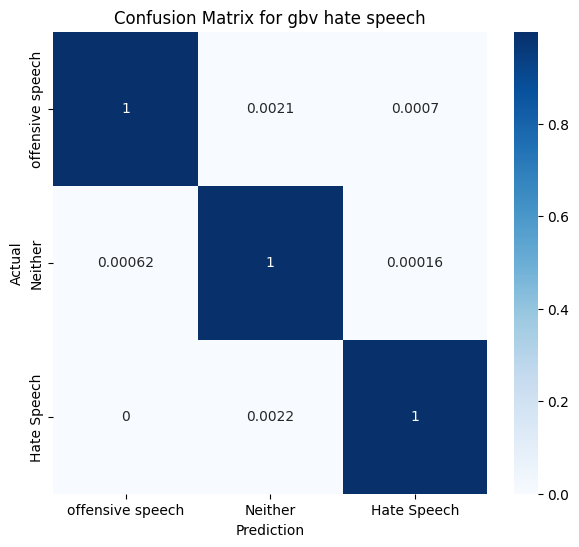

In [40]:
plot_com(emotion_labels, emotion_pred, 'Confusion Matrix for Emotion', emotion_labels_text)
plot_com(violence_labels, violence_pred, 'Confusion Matrix for violence', violence_labels_text)
plot_com(gbv_hate_speech_labels, gbv_hate_speech_pred, 'Confusion Matrix for gbv hate speech', gbv_hate_speech_labels_text)

In [46]:
""" Manual Testing """
def classify_text(input_text):
    # Preprocess the input text
    input_text_cleaned = remove_stopwords(input_text)
    input_sequences = tokenizer.texts_to_sequences([input_text_cleaned])
    input_padded = pad_sequences(input_sequences, maxlen = max_length, padding = 'post')

    # Prediction
    predictions = model.predict({
        'emotion_input' : input_padded,
        'violence_input' : input_padded,
        'gbv_hate_speech_input' : input_padded
    })
    emotion_pred = np.argmax(predictions[0], axis = 1)[0]
    violence_pred = np.argmax(predictions[1], axis = 1)[0]
    gbv_hate_speech_pred = np.argmax(predictions[2], axis = 1)[0]

    # Determine major label
    major_labels = ['Emotion', 'Violence', 'Hate']
    major_labels_index = np.argmax([np.max(predictions[0]), np.max(predictions[1]), np.max(predictions[2])])
    major_label = major_labels[major_labels_index]

    # Determining sub-labels
    emotion_labels_text = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
    violence_labels_text = ['sexual_violence','physical_violence','emotional_violence','Harmful_traditional_practice','economic violence']
    gbv_hate_speech_labels_text = ['offensive speech', 'Neither', 'Hate Speech']

    if major_label == 'Emotion':
        sub_label = emotion_labels_text[emotion_pred]
    elif major_label == 'Violence':
        sub_label = violence_labels_text[violence_pred]
    else:
        sub_label = gbv_hate_speech_labels_text[gbv_hate_speech_pred]
    return major_label, sub_label

In [42]:
import ipywidgets as widgets
from IPython.display import display

In [43]:
# Define a widget and a placeholder
input_text_widget = widgets.Text(
    description='Input Text: ',
    placeholder='Enter Text: ',
)

In [44]:
# Define classify button
button = widgets.Button(description='Classify Text')

# Define an output area to display result
output = widgets.Output(layout={'width': '100%'})

In [47]:
# Define function to handle event
def on_button_Click(button):
    with output:
        output.clear_output()
        input_text = input_text_widget.value
        major_label, sub_label = classify_text(input_text)
        print(f'Major label : {major_label}\nSub label : {sub_label}')

# Attach the button at the bottom
button.on_click(on_button_Click)

display(input_text_widget, button, output)

Text(value='', description='Input Text: ', placeholder='Enter Text: ')

Button(description='Classify Text', style=ButtonStyle())

Output(layout=Layout(width='100%'))